In [1]:
import os
import io
import time
import random
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import librosa
import librosa.display
import soundfile as sf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from tqdm import tqdm

# Display settings
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 4)

In [ ]:
DATASET_DIR = r"C:\Users\Lenovo\Documents\projects\research\Major-Project\Forest-Audio\data\audio"
METADATA_FILE = r"C:\Users\Lenovo\Documents\projects\research\Major-Project\Forest-Audio\data\metadata.csv"
OUTPUT_DIR = r"C:\Users\Lenovo\Documents\projects\research\Major-Project\Forest-Audio\data\processed_audio"
os.makedirs(OUTPUT_DIR, exist_ok=True)

SAMPLE_RATE = 44100
FIXED_DURATION = 5.0  # seconds
HOP_LENGTH = 512
MFCC_LIST = [8, 16, 32, 64, 128]
RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

print(f"✓ Output directory: {OUTPUT_DIR}")
print(f"✓ MFCC configurations: {MFCC_LIST}")

✓ Output directory: C:\Users\Lenovo\Documents\projects\research\Major-Project\Forest-Audio\data\processed_audio
✓ MFCC configurations: [8, 16, 32, 64, 128]


Metadata rows: 2025


,Source File Name,Dataset File Name,Class ID,Class Name
0,17548__A.wav,1_10101.wav,1,Fire
1,17548_B.wav,1_10102.wav,1,Fire
2,17548_C.wav,1_10103.wav,1,Fire
3,17548_D.wav,1_10104.wav,1,Fire
4,17548_E.wav,1_10105.wav,1,Fire


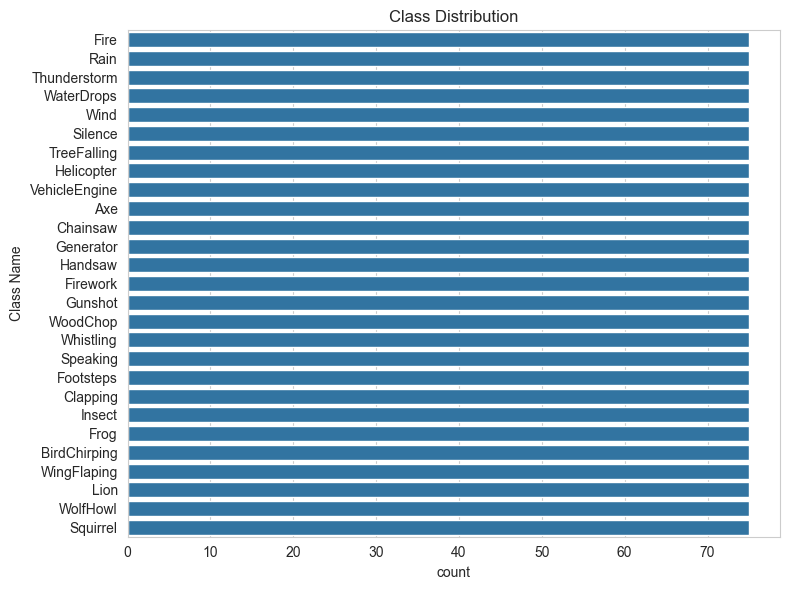

✓ Found 27 unique classes


In [3]:
metadata = pd.read_csv(METADATA_FILE)
print(f"Metadata rows: {len(metadata)}")
display(metadata.head())

# Class distribution
plt.figure(figsize=(8, 6))
sns.countplot(y="Class Name", data=metadata, order=metadata["Class Name"].value_counts().index)
plt.title("Class Distribution")
plt.tight_layout()
plt.show()

# Ensure required column exists
if "Dataset File Name" not in metadata.columns:
    raise KeyError("Metadata must have column 'Dataset File Name' with relative file names.")

print(f"✓ Found {metadata['Class Name'].nunique()} unique classes")

In [4]:
def load_and_fix_audio(file_path, sr=SAMPLE_RATE, fixed_duration=FIXED_DURATION):
    """Load audio, pad/trim to fixed duration, and normalize"""
    y, _sr = librosa.load(file_path, sr=sr)
    target_len = int(fixed_duration * sr)
    
    if len(y) < target_len:
        y = np.pad(y, (0, target_len - len(y)), mode='constant')
    else:
        y = y[:target_len]
    
    # Normalize amplitude (peak normalize)
    y = librosa.util.normalize(y)
    return y, sr


In [5]:
def plot_waveform(y, sr, title="Waveform"):
    plt.figure(figsize=(10, 2.5))
    librosa.display.waveshow(y, sr=sr)
    plt.title(title)
    plt.tight_layout()
    plt.show()

def plot_spectrogram(y, sr, n_fft=2048, hop_length=HOP_LENGTH, title="Spectrogram (dB)"):
    D = np.abs(librosa.stft(y, n_fft=n_fft, hop_length=hop_length))
    DB = librosa.amplitude_to_db(D, ref=np.max)
    plt.figure(figsize=(10, 4))
    librosa.display.specshow(DB, sr=sr, hop_length=hop_length, x_axis='time', y_axis='linear')
    plt.colorbar(format="%+2.0f dB")
    plt.title(title)
    plt.tight_layout()
    plt.show()

def plot_mel_spectrogram(y, sr, n_fft=2048, hop_length=HOP_LENGTH, n_mels=128, title="Mel Spectrogram (dB)"):
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=n_fft, hop_length=hop_length, n_mels=n_mels)
    S_db = librosa.power_to_db(S, ref=np.max)
    plt.figure(figsize=(10, 4))
    librosa.display.specshow(S_db, sr=sr, hop_length=hop_length, x_axis='time', y_axis='mel')
    plt.colorbar(format="%+2.0f dB")
    plt.title(title)
    plt.tight_layout()
    plt.show()

def plot_mfcc_heatmap(y, sr, n_mfcc=128, hop_length=HOP_LENGTH, title="MFCC"):
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc, hop_length=hop_length)
    plt.figure(figsize=(10, 4))
    librosa.display.specshow(mfcc, x_axis='time', sr=sr, hop_length=hop_length)
    plt.colorbar()
    plt.title(f"{title} (n_mfcc={n_mfcc})")
    plt.tight_layout()
    plt.show()

def plot_delta_mfcc(y, sr, n_mfcc=128, hop_length=HOP_LENGTH, title="Delta MFCC"):
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc, hop_length=hop_length)
    delta = librosa.feature.delta(mfcc)
    delta2 = librosa.feature.delta(mfcc, order=2)
    
    plt.figure(figsize=(10, 4))
    plt.subplot(3, 1, 1)
    librosa.display.specshow(mfcc, x_axis='time', sr=sr, hop_length=hop_length)
    plt.title("MFCC")
    plt.colorbar()
    
    plt.subplot(3, 1, 2)
    librosa.display.specshow(delta, x_axis='time', sr=sr, hop_length=hop_length)
    plt.title("Delta (1st order)")
    plt.colorbar()
    
    plt.subplot(3, 1, 3)
    librosa.display.specshow(delta2, x_axis='time', sr=sr, hop_length=hop_length)
    plt.title("Delta-Delta (2nd order)")
    plt.colorbar()
    
    plt.tight_layout()
    plt.show()

def plot_rms(y, sr, hop_length=HOP_LENGTH, title="RMS Energy"):
    rms = librosa.feature.rms(y=y, hop_length=hop_length)[0]
    times = librosa.times_like(rms, sr=sr, hop_length=hop_length)
    plt.figure(figsize=(10, 3))
    plt.plot(times, rms)
    plt.xlabel("Time (s)")
    plt.title(title)
    plt.tight_layout()
    plt.show()

def plot_zcr(y, sr, hop_length=HOP_LENGTH, title="Zero Crossing Rate"):
    zcr = librosa.feature.zero_crossing_rate(y, hop_length=hop_length)[0]
    times = librosa.times_like(zcr, sr=sr, hop_length=hop_length)
    plt.figure(figsize=(10, 3))
    plt.plot(times, zcr)
    plt.xlabel("Time (s)")
    plt.title(title)
    plt.tight_layout()
    plt.show()

def plot_amplitude_hist(y, bins=80, title="Amplitude Histogram"):
    plt.figure(figsize=(6, 3))
    plt.hist(y, bins=bins)
    plt.title(title)
    plt.tight_layout()
    plt.show()

In [6]:
n_random_global = 5
random_indices = metadata.sample(n=min(n_random_global, len(metadata)), random_state=RANDOM_SEED).index.tolist()

# One sample per class (first occurrence)
per_class_samples = {}
for idx, row in metadata.iterrows():
    cname = row["Class Name"]
    if cname not in per_class_samples:
        per_class_samples[cname] = row["Dataset File Name"]

print(f"✓ Selected {len(random_indices)} random samples and {len(per_class_samples)} class samples.")


✓ Selected 5 random samples and 27 class samples.


Visualizing global random samples...


  0%|          | 0/5 [00:00<?, ?it/s]

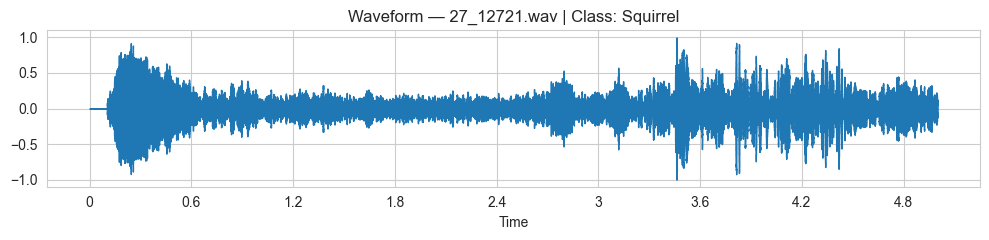

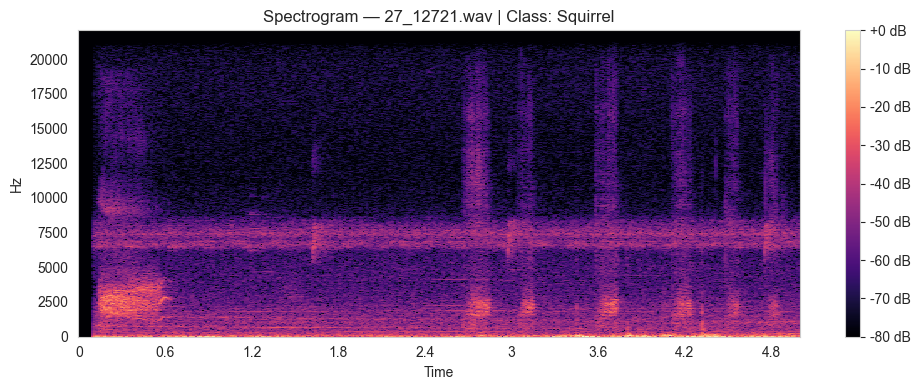

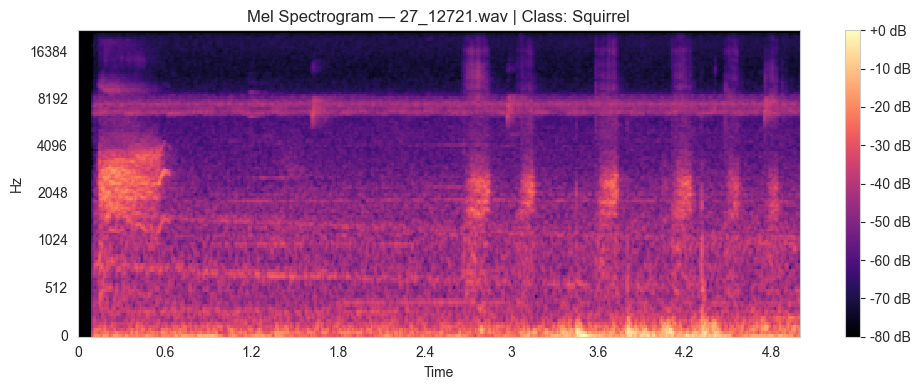

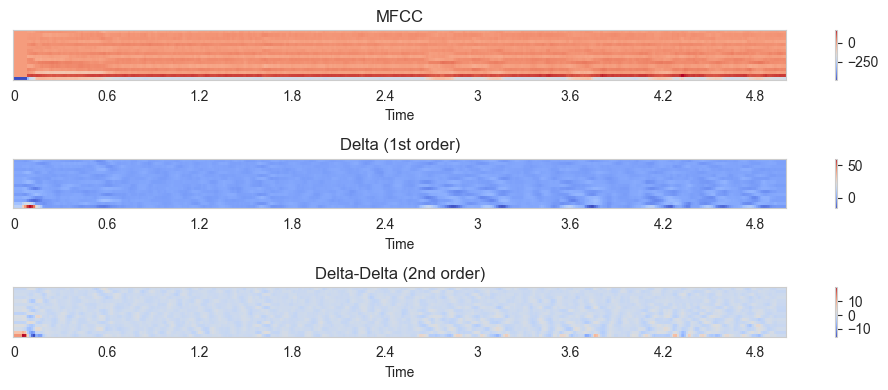

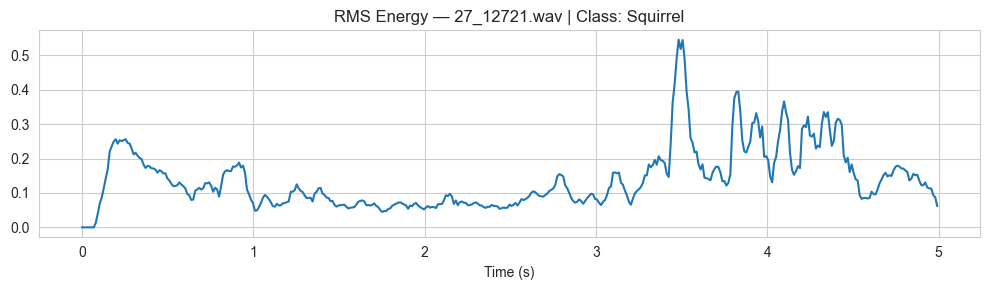

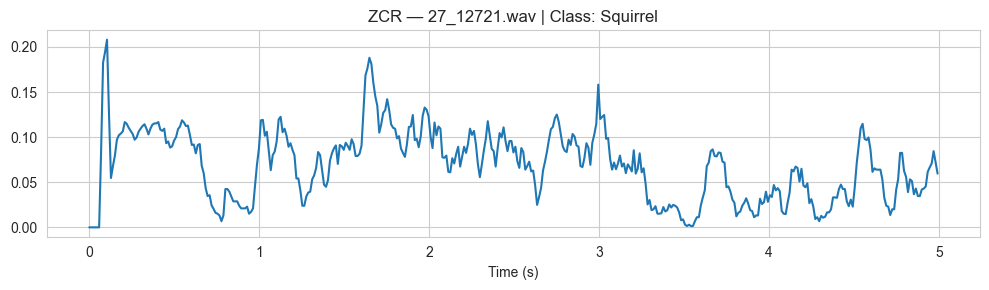

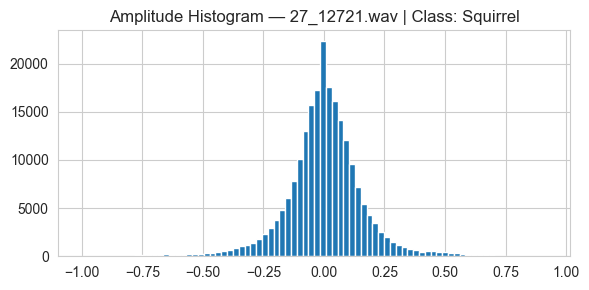

 20%|██        | 1/5 [00:02<00:08,  2.16s/it]

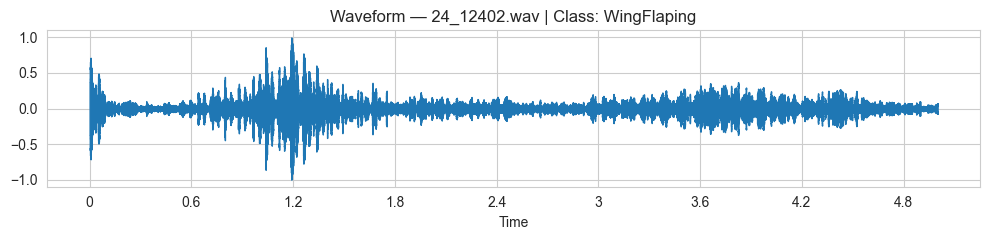

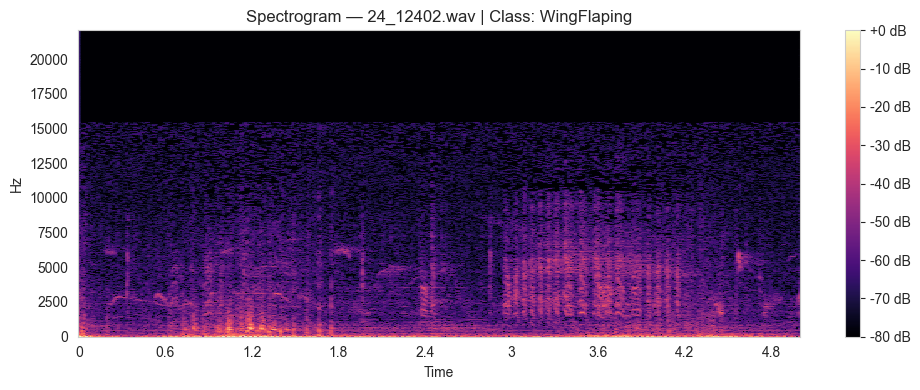

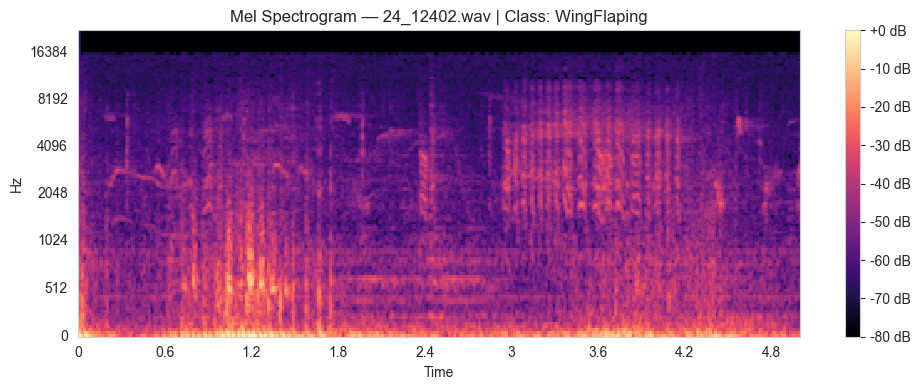

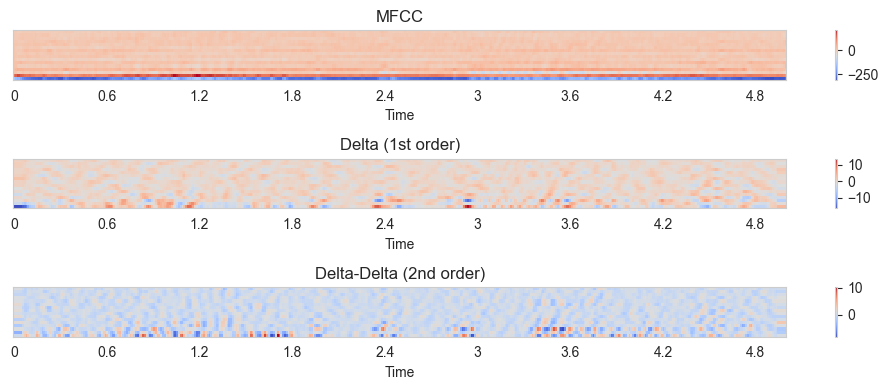

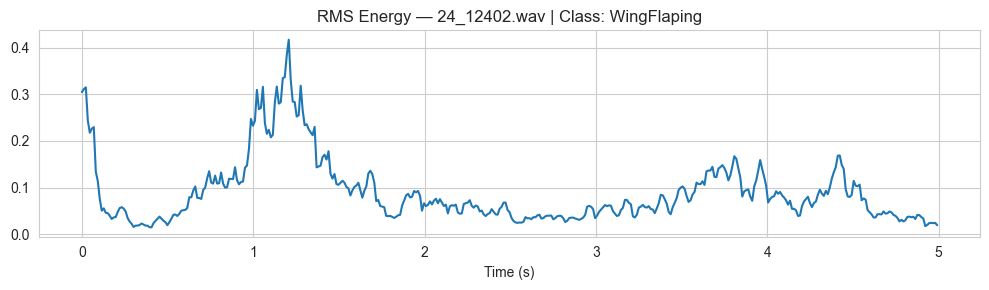

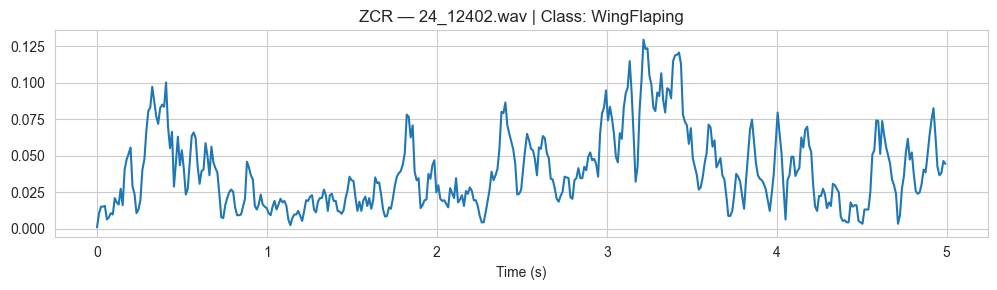

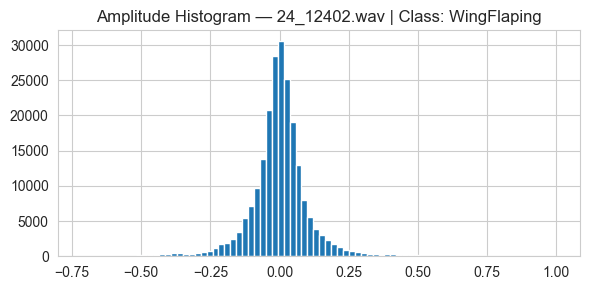

 40%|████      | 2/5 [00:04<00:07,  2.55s/it]

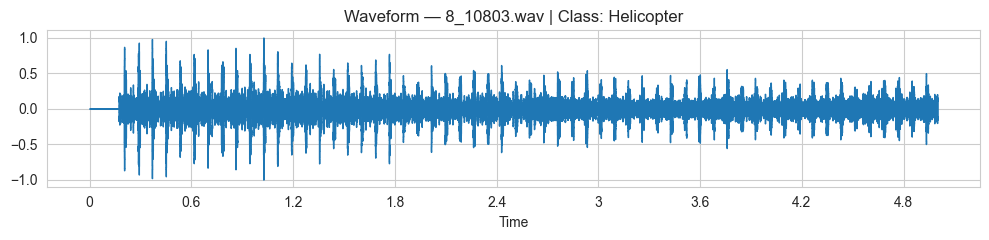

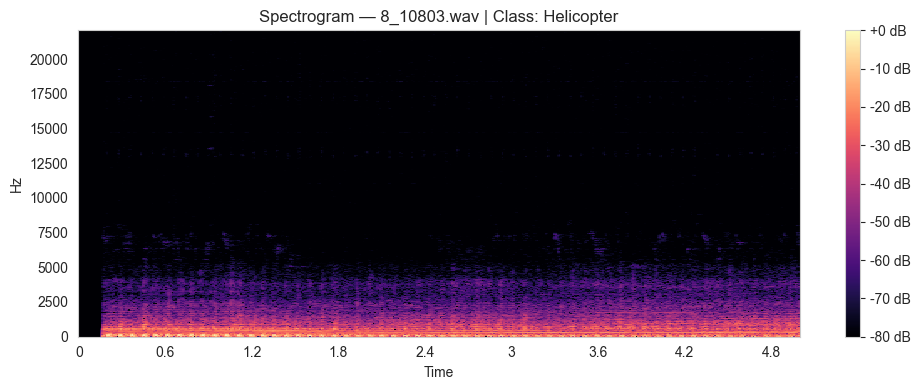

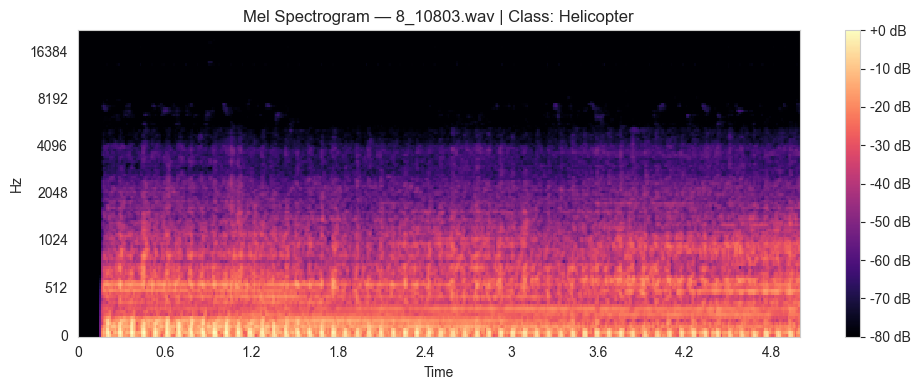

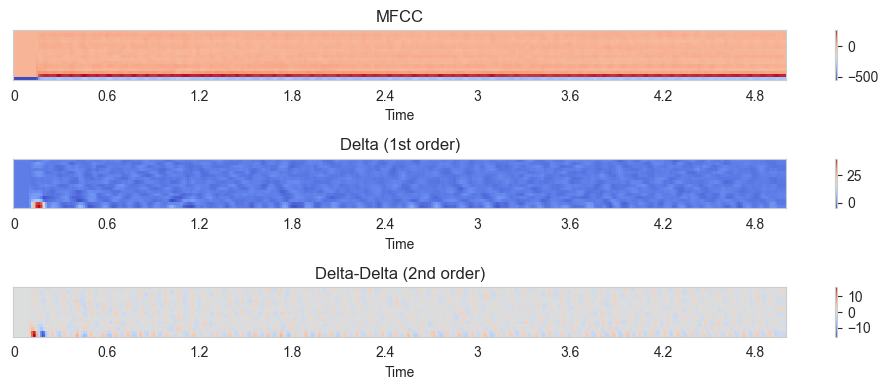

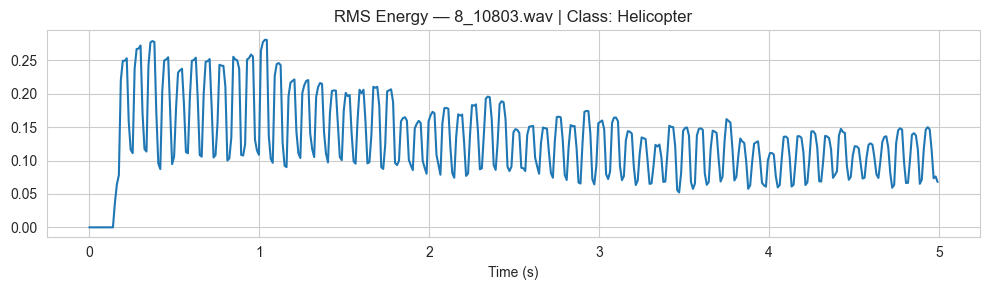

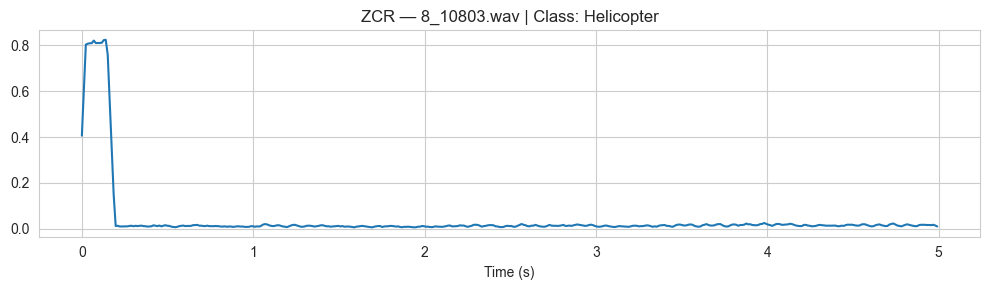

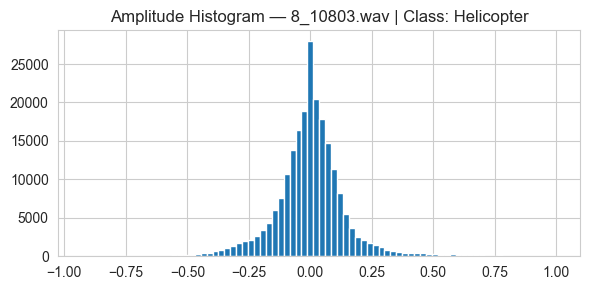

 60%|██████    | 3/5 [00:07<00:05,  2.52s/it]

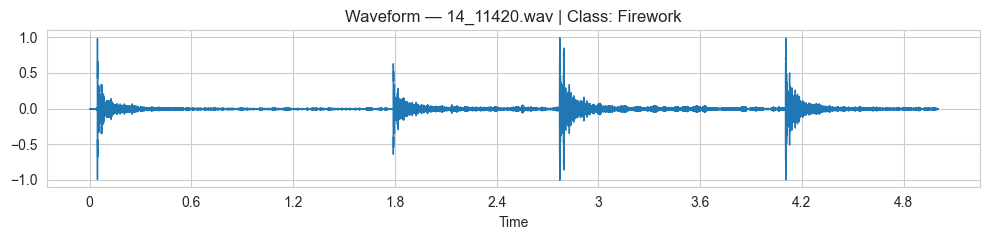

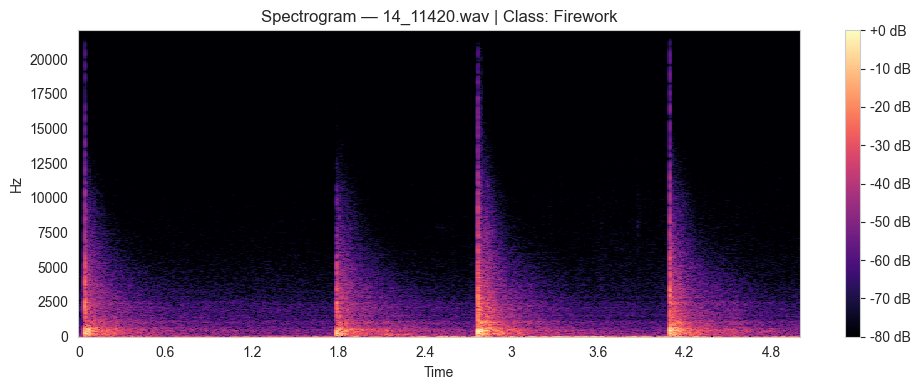

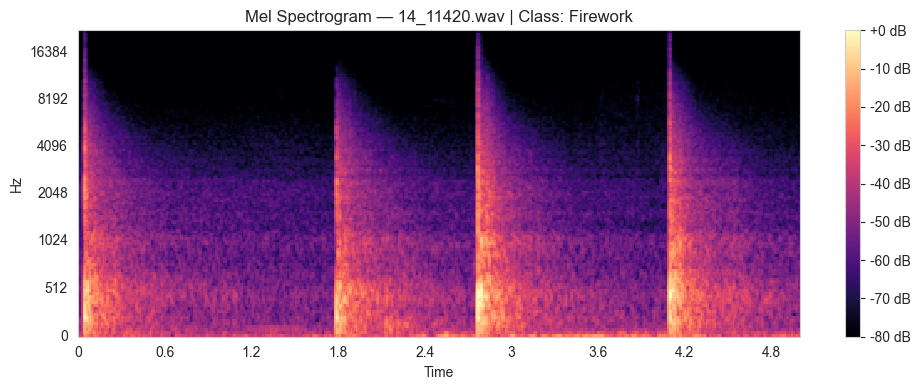

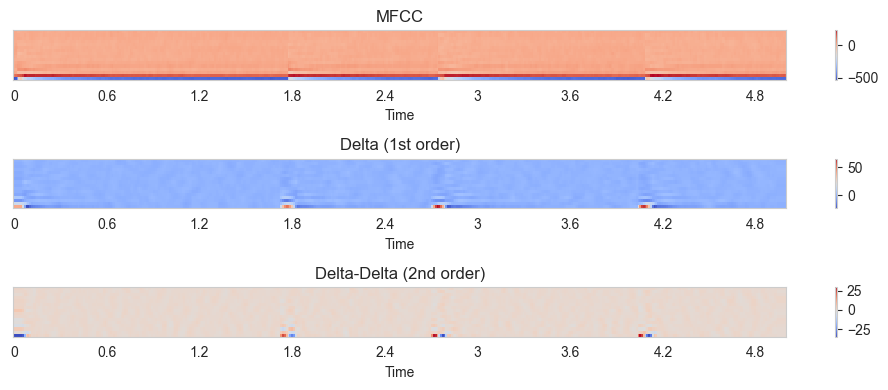

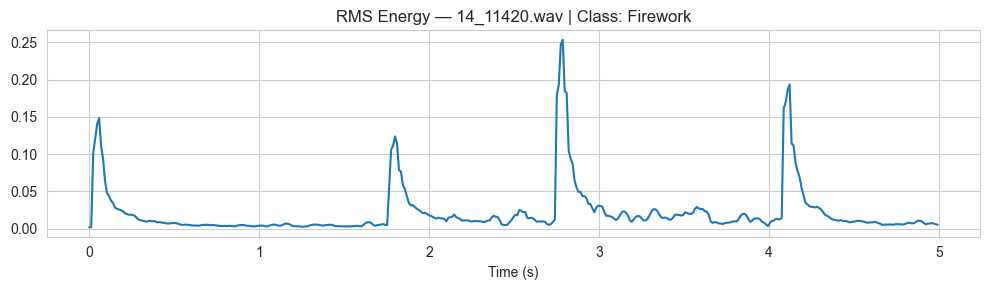

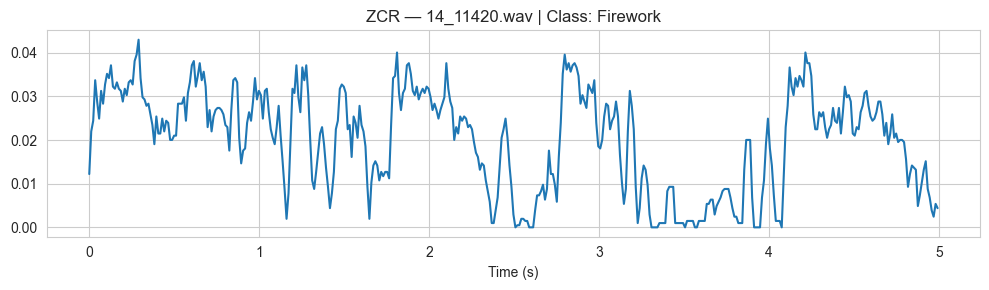

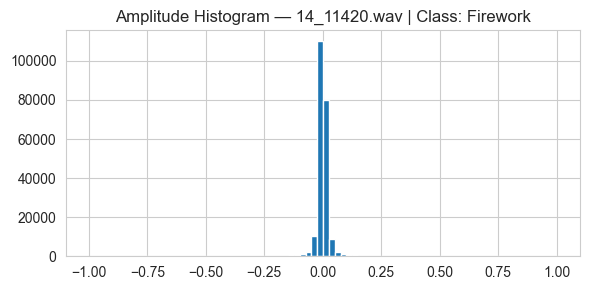

 80%|████████  | 4/5 [00:09<00:02,  2.44s/it]

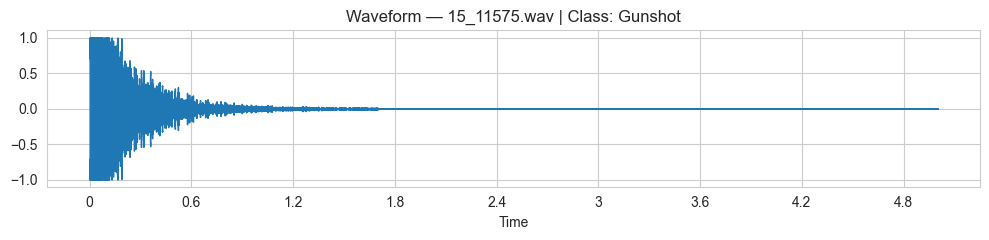

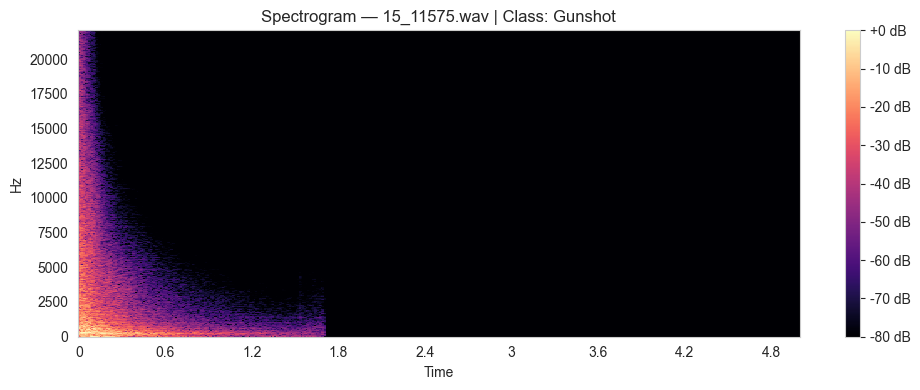

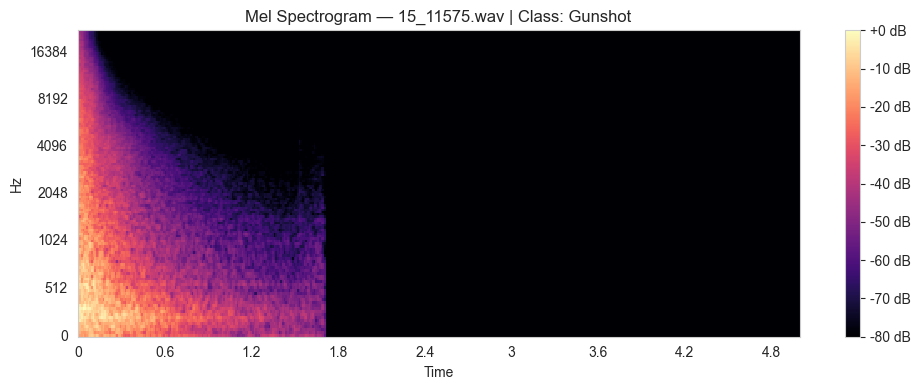

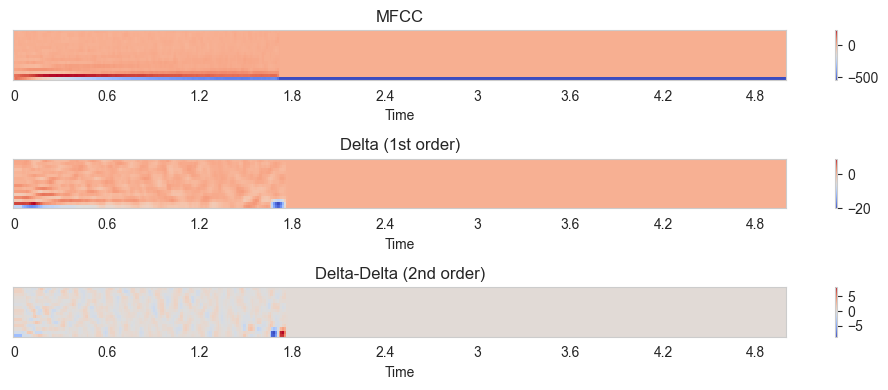

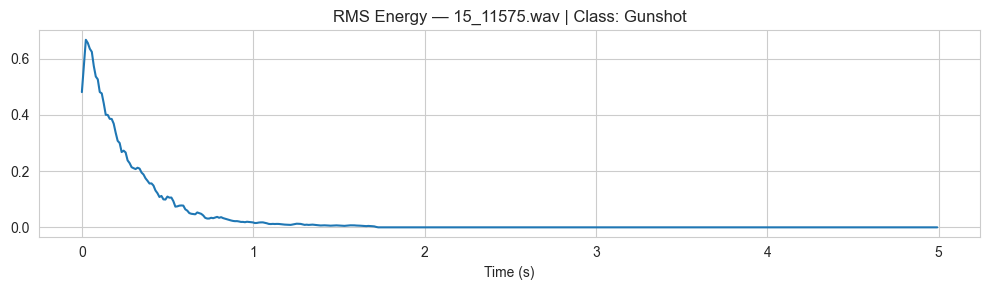

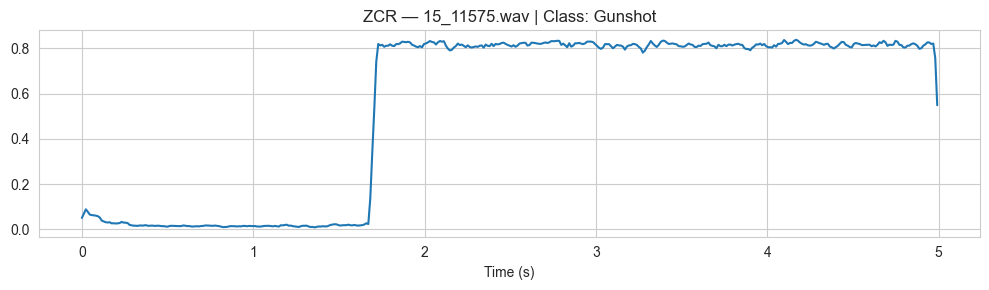

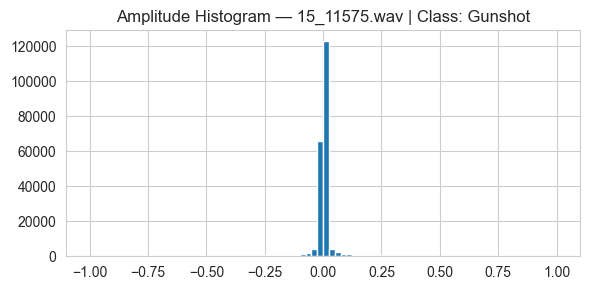

100%|██████████| 5/5 [00:12<00:00,  2.43s/it]


In [14]:
print("Visualizing global random samples...")
for idx in tqdm(random_indices):
    row = metadata.loc[idx]
    file_path = os.path.join(DATASET_DIR, row["Dataset File Name"])
    
    if not os.path.exists(file_path):
        print(f"File not found: {file_path}")
        continue
    
    y, sr = load_and_fix_audio(file_path)
    title_base = f"{row['Dataset File Name']} | Class: {row['Class Name']}"
    
    plot_waveform(y, sr, title=f"Waveform — {title_base}")
    plot_spectrogram(y, sr, title=f"Spectrogram — {title_base}")
    plot_mel_spectrogram(y, sr, title=f"Mel Spectrogram — {title_base}")
    # plot_mfcc_heatmap(y, sr, n_mfcc=32, title=f"MFCC (preview) — {title_base}")
    plot_delta_mfcc(y, sr, n_mfcc=16, title=f"Delta MFCC — {title_base}")
    plot_rms(y, sr, title=f"RMS Energy — {title_base}")
    plot_zcr(y, sr, title=f"ZCR — {title_base}")
    plot_amplitude_hist(y, title=f"Amplitude Histogram — {title_base}")



In [9]:
comparison_rows = []
y_train_saved = None
y_test_saved = None

for n_mfcc in MFCC_LIST:
    print(f"\nProcessing MFCC config: n_mfcc = {n_mfcc}")
    features = []
    labels = []
    times = []
    missing_files = 0
    
    for idx, row in tqdm(metadata.iterrows(), total=len(metadata)):
        file_path = os.path.join(DATASET_DIR, row["Dataset File Name"])
        
        if not os.path.exists(file_path):
            missing_files += 1
            continue
        
        start = time.perf_counter()
        try:
            y, sr = load_and_fix_audio(file_path)
            
            # MFCC extraction
            mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc, hop_length=HOP_LENGTH)
            
            # Mean pooling across time
            mfcc_mean = np.mean(mfcc.T, axis=0)
            features.append(mfcc_mean.astype(np.float32))
            labels.append(row["Class ID"])
        except Exception as e:
            print(f"Error processing {file_path}: {e}")
            continue
        
        end = time.perf_counter()
        times.append(end - start)
    
    features = np.array(features)
    labels = np.array(labels)
    n_files = features.shape[0]
    
    print(f"Files processed: {n_files} (Missing: {missing_files})")
    
    if n_files == 0:
        print(f"No files for n_mfcc={n_mfcc}, skipping.")
        continue
    
    # Compute metrics
    features_shape = features.shape
    mem_bytes_in_memory = features.nbytes
    mean_variance = np.mean(np.var(features, axis=0))
    avg_time_per_file = np.mean(times) if times else np.nan
    
    # Scale features
    scaler = StandardScaler()
    features_scaled = scaler.fit_transform(features)
    
    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        features_scaled, labels, test_size=0.2, stratify=labels, random_state=RANDOM_SEED
    )
    
    # Save arrays
    X_train_fname = os.path.join(OUTPUT_DIR, f"X_train_{n_mfcc}.npy")
    X_test_fname = os.path.join(OUTPUT_DIR, f"X_test_{n_mfcc}.npy")
    y_train_fname = os.path.join(OUTPUT_DIR, "y_train.npy")
    y_test_fname = os.path.join(OUTPUT_DIR, "y_test.npy")
    
    np.save(X_train_fname, X_train)
    np.save(X_test_fname, X_test)
    
    if y_train_saved is None:
        np.save(y_train_fname, y_train)
        np.save(y_test_fname, y_test)
        y_train_saved = y_train
        y_test_saved = y_test
    
    # Compute on-disk size
    size_X_train = os.path.getsize(X_train_fname)
    size_X_test = os.path.getsize(X_test_fname)
    total_disk_bytes = size_X_train + size_X_test
    
    comparison_rows.append({
        "n_mfcc": n_mfcc,
        "n_files": n_files,
        "features_shape": features_shape,
        "mem_bytes_in_memory": int(mem_bytes_in_memory),
        "disk_bytes_saved": int(total_disk_bytes),
        "mean_variance": float(mean_variance),
        "avg_time_per_file_sec": float(avg_time_per_file)
    })

# Create comparison DataFrame
comparison_df = pd.DataFrame(comparison_rows).sort_values("n_mfcc")
display(comparison_df)


Processing MFCC config: n_mfcc = 8


100%|██████████| 2025/2025 [01:29<00:00, 22.60it/s]


Files processed: 2025 (Missing: 0)

Processing MFCC config: n_mfcc = 16


100%|██████████| 2025/2025 [00:55<00:00, 36.20it/s]


Files processed: 2025 (Missing: 0)

Processing MFCC config: n_mfcc = 32


...

100%|██████████| 2025/2025 [00:47<00:00, 42.80it/s]


Files processed: 2025 (Missing: 0)

Processing MFCC config: n_mfcc = 128


100%|██████████| 2025/2025 [00:50<00:00, 40.41it/s]


Files processed: 2025 (Missing: 0)


,n_mfcc,n_files,features_shape,mem_bytes_in_memory,disk_bytes_saved,mean_variance,avg_time_per_file_sec
0,8,2025,"(2025, 8)",64800,65056,3492.593506,0.043328
1,16,2025,"(2025, 16)",129600,129856,1781.610107,0.026993
2,32,2025,"(2025, 32)",259200,259456,900.863342,0.022717
3,64,2025,"(2025, 64)",518400,518656,452.415771,0.022830
4,128,2025,"(2025, 128)",1036800,1037056,226.432175,0.024166


,n_mfcc,n_files,features_length,mem_kb,disk_kb,mean_variance,avg_time_per_file_sec
0,8,2025,8,63.28125,63.53125,3492.593506,0.043328
1,16,2025,16,126.56250,126.81250,1781.610107,0.026993
2,32,2025,32,253.12500,253.37500,900.863342,0.022717
3,64,2025,64,506.25000,506.50000,452.415771,0.022830
4,128,2025,128,1012.50000,1012.75000,226.432175,0.024166


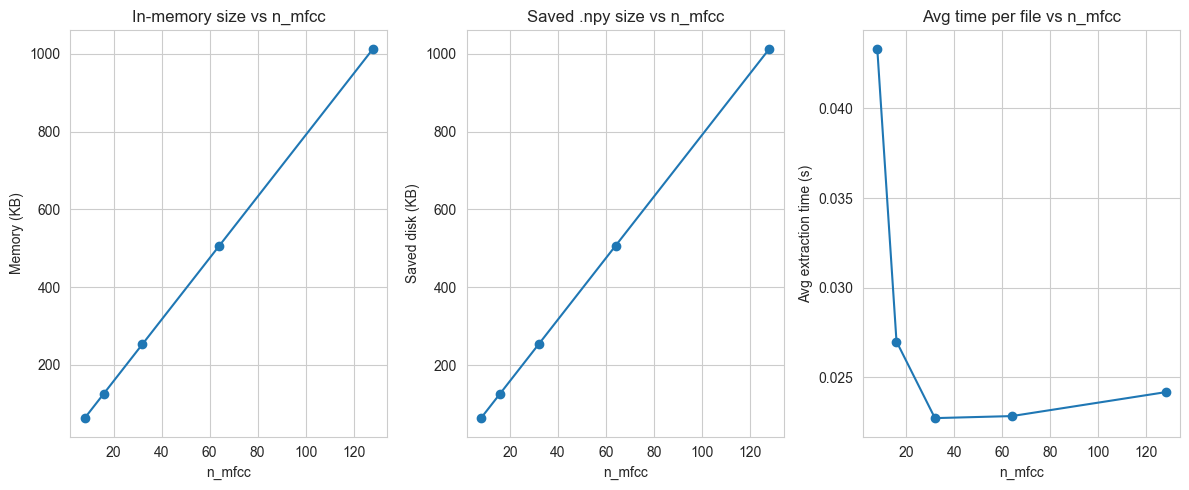

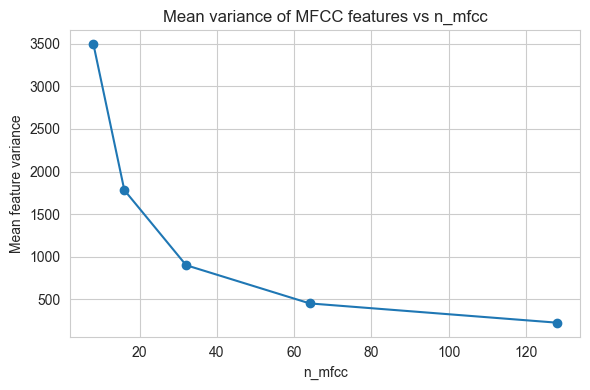

In [10]:
comparison_df["mem_kb"] = comparison_df["mem_bytes_in_memory"] / 1024
comparison_df["disk_kb"] = comparison_df["disk_bytes_saved"] / 1024
comparison_df["features_length"] = comparison_df["features_shape"].apply(
    lambda x: x[1] if isinstance(x, (tuple, list)) else None
)

display_columns = ["n_mfcc", "n_files", "features_length", "mem_kb", "disk_kb", 
                   "mean_variance", "avg_time_per_file_sec"]
display(comparison_df[display_columns])

# Memory/Disk/Time plots
plt.figure(figsize=(12, 5))

plt.subplot(1, 3, 1)
plt.plot(comparison_df["n_mfcc"], comparison_df["mem_kb"], marker='o')
plt.xlabel("n_mfcc")
plt.ylabel("Memory (KB)")
plt.title("In-memory size vs n_mfcc")

plt.subplot(1, 3, 2)
plt.plot(comparison_df["n_mfcc"], comparison_df["disk_kb"], marker='o')
plt.xlabel("n_mfcc")
plt.ylabel("Saved disk (KB)")
plt.title("Saved .npy size vs n_mfcc")

plt.subplot(1, 3, 3)
plt.plot(comparison_df["n_mfcc"], comparison_df["avg_time_per_file_sec"], marker='o')
plt.xlabel("n_mfcc")
plt.ylabel("Avg extraction time (s)")
plt.title("Avg time per file vs n_mfcc")

plt.tight_layout()
plt.show()

# Variance plot
plt.figure(figsize=(6, 4))
plt.plot(comparison_df["n_mfcc"], comparison_df["mean_variance"], marker='o')
plt.xlabel("n_mfcc")
plt.ylabel("Mean feature variance")
plt.title("Mean variance of MFCC features vs n_mfcc")
plt.tight_layout()
plt.show()

In [12]:
for n_mfcc in MFCC_LIST:
    X_train_fname = os.path.join(OUTPUT_DIR, f"X_train_{n_mfcc}.npy")
    if os.path.exists(X_train_fname):
        arr = np.load(X_train_fname)
        print(f"{os.path.basename(X_train_fname)} shape: {arr.shape}, dtype: {arr.dtype}")
    else:
        print(f"{X_train_fname} not found.")

X_train_8.npy shape: (1620, 8), dtype: float32
X_train_16.npy shape: (1620, 16), dtype: float32
X_train_32.npy shape: (1620, 32), dtype: float32
X_train_64.npy shape: (1620, 64), dtype: float32
X_train_128.npy shape: (1620, 128), dtype: float32


In [13]:
# Cell 14: Save Comparison Table
comparison_csv = os.path.join(OUTPUT_DIR, "mfcc_comparison_metrics.csv")
comparison_df.to_csv(comparison_csv, index=False)
print(f"✓ Comparison metrics saved to: {comparison_csv}")

✓ Comparison metrics saved to: C:\Users\Lenovo\Documents\projects\research\Major-Project\Forest-Audio\data\processed_audio\mfcc_comparison_metrics.csv
